<a href="https://colab.research.google.com/github/mayashah100/MEI-Data-Science-Project/blob/main/MEI_DataScienceCourse_Lesson5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MEI Introduction to Data Science: Lesson 5 - Activity 1

# Introduction

The problem in this activity is an introduction to one type of *machine learning*. In it you will explore how the values in one or more features in a dataset can be used to build a model to predict the values of another feature.

The activity uses the data from the AQA large data set which gives information about cars. You met this data set in Lesson 2. For more information about the data see the short video at: https://mei.org.uk/introduction-to-data-science/large-data-sets/

## Problem
***Can engine size and mass be used to predict a car's $CO_2$ emissions?***

To answer this question you could find statistics and create charts of the masses and emissions of petrol and diesel cars in the dataset. You can then build a model that predicts emissions and evaluate it.

## Importing libraries and data

You are going to build models for predicting $CO_2$ emissions. To begin with, you will look at simple linear functions of one variable: this is the same as *drawing a line of best fit* or *finding a regression line*. To do this you will need to import two functions from the `sklearn` library.

`sklearn` is the *scikit-learn* library that contains machine learning commands for building models. You do not need the full library so the functions `LinearRegression` (for creating the model) and `r2_score` (for evaluating the model) are imported individually.

> Run the code boxes below to import the libraries and the data.

In [ ]:
# import pandas
import pandas as pd

#import seaborn for plotting
import seaborn as sns

# import LinearRegression (for creating the model), r2_score (for evaluating the model) and the training-testing split command
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [ ]:
# importing the data https://drive.google.com/file/d/1N632vbSCqG6i1DLYYIjFB6fxAFciacWv/view?usp=drive_link
!gdown '1N632vbSCqG6i1DLYYIjFB6fxAFciacWv'
cars_data = pd.read_csv('../content/AQA-large-data-set.csv')

# inspecting the data to check that it has imported correctly
cars_data

Downloading...
From: https://drive.google.com/uc?id=1N632vbSCqG6i1DLYYIjFB6fxAFciacWv
To: /content/AQA-large-data-set.csv
100% 299k/299k [00:00<00:00, 57.3MB/s]


,ReferenceNumber,Make,PropulsionTypeId,BodyTypeId,GovRegion,KeeperTitleId,EngineSize,YearRegistered,Mass,CO2,CO,NOX,part,hc,Random number
0,440,VAUXHALL,1,96,London,1,1598,2002,1970,190,0.219,0.026,NaN,0.037,0.430217
1,1465,VAUXHALL,1,14,South West,5,1398,2016,1163,118,0.463,0.010,NaN,0.031,0.797111
2,3434,VOLKSWAGEN,1,14,South West,2,1395,2016,1316,113,0.242,0.033,NaN,0.048,0.348442
3,1801,VAUXHALL,1,14,South West,4,1598,2016,1355,159,0.809,0.012,NaN,0.051,0.968447
4,2330,BMW,2,13,South West,5,1995,2016,1445,114,0.180,0.023,NaN,NaN,0.178227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3822,2920,FORD,2,14,North West,5,1997,2016,1681,122,0.145,0.059,0.001,NaN,0.946550
3823,1800,FORD,2,96,London,2,1997,2016,1833,134,0.305,0.054,NaN,NaN,0.538774
3824,3498,FORD,1,14,South West,1,999,2016,1333,108,0.447,0.030,0.002,0.076,0.736612
3825,2802,VAUXHALL,1,14,North West,5,1364,2016,1409,149,0.699,0.008,NaN,0.044,0.748846


# Exploring connections between mass, engine size and CO2 emissions

## Pre-processing the data

The following code cleans and prepares the data in the same you saw earlier in the course. Refer to Lesson 2, Activity 1 for an explanation of these steps.

> Run the code below to clean and prepare the data.

In [ ]:
# Keeping only the rows where EngineSize is greater than zero, Mass is greater than zero and CO2 is greater than zero
cleaned_cars_data = cars_data[(cars_data['EngineSize'] > 0) & (cars_data['Mass'] > 0) & (cars_data['CO2'] > 0)].copy()

# create a PropulsionType feature based on the values of the PropulsionTypeID feature
cleaned_cars_data['PropulsionType'] = cars_data['PropulsionTypeId'].replace({1: 'Petrol',
                                                                             2: 'Diesel',
                                                                             3: 'Electric',
                                                                             7: 'Gas/Petrol',
                                                                             8: 'Electric/Petrol'})
# check the data
cleaned_cars_data

,ReferenceNumber,Make,PropulsionTypeId,BodyTypeId,GovRegion,KeeperTitleId,EngineSize,YearRegistered,Mass,CO2,CO,NOX,part,hc,Random number,PropulsionType
0,440,VAUXHALL,1,96,London,1,1598,2002,1970,190,0.219,0.026,NaN,0.037,0.430217,Petrol
1,1465,VAUXHALL,1,14,South West,5,1398,2016,1163,118,0.463,0.010,NaN,0.031,0.797111,Petrol
2,3434,VOLKSWAGEN,1,14,South West,2,1395,2016,1316,113,0.242,0.033,NaN,0.048,0.348442,Petrol
3,1801,VAUXHALL,1,14,South West,4,1598,2016,1355,159,0.809,0.012,NaN,0.051,0.968447,Petrol
4,2330,BMW,2,13,South West,5,1995,2016,1445,114,0.180,0.023,NaN,NaN,0.178227,Diesel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3822,2920,FORD,2,14,North West,5,1997,2016,1681,122,0.145,0.059,0.001,NaN,0.946550,Diesel
3823,1800,FORD,2,96,London,2,1997,2016,1833,134,0.305,0.054,NaN,NaN,0.538774,Diesel
3824,3498,FORD,1,14,South West,1,999,2016,1333,108,0.447,0.030,0.002,0.076,0.736612,Petrol
3825,2802,VAUXHALL,1,14,North West,5,1364,2016,1409,149,0.699,0.008,NaN,0.044,0.748846,Petrol


## Exploring the data

You can use a scatter diagram to explore the association between a numerical feature and the $CO_2$ emissions.

> Run the code below to create a scatter diagram for $CO_2$ emissions against mass.

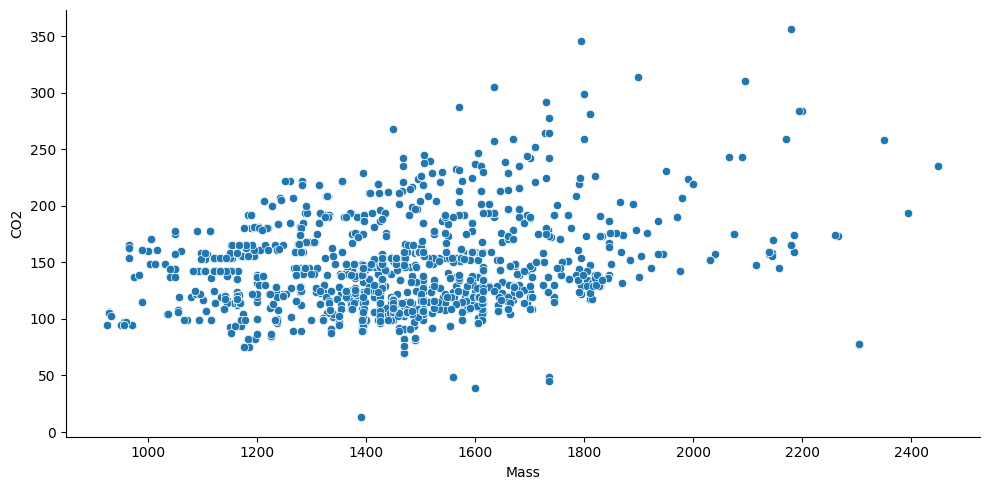

In [ ]:
# create a scatter diagram for CO2 emissions against mass
sns.relplot(data=cleaned_cars_data, x='Mass', y='CO2', aspect=2);

> Create a scatter diagram for the CO2 emissions (plotted on the $y$-axis) against `EngineSize` (plotted on the $x$-axis).

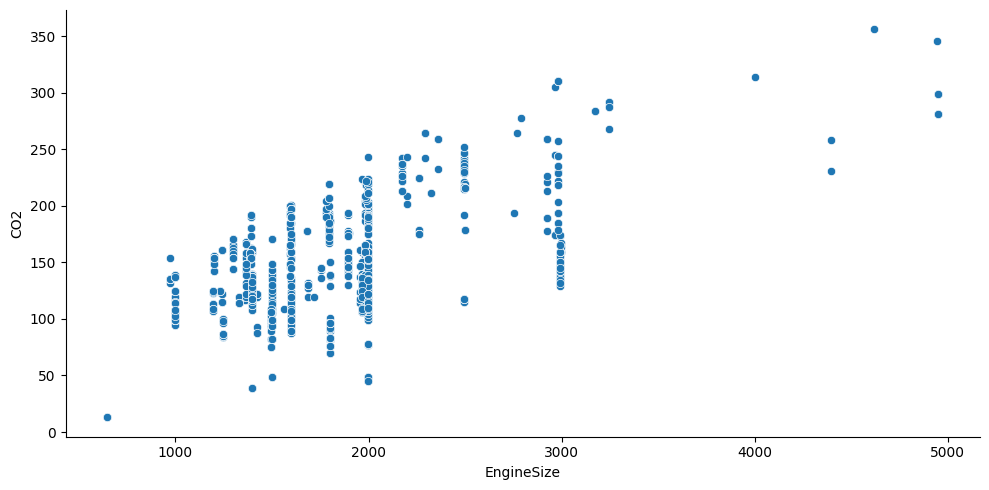

In [ ]:
# create a scatter diagram for CO2 emissions against EngineSize
sns.relplot(data=cleaned_cars_data, x='EngineSize', y='CO2', aspect=2)

You can see what effect propulsion type has on emissions by adding that as third variable to a scatter plot.

> Run the code below to create a scatter plot of `CO2` against `Mass`, colour-coded by `PropulsionType`.

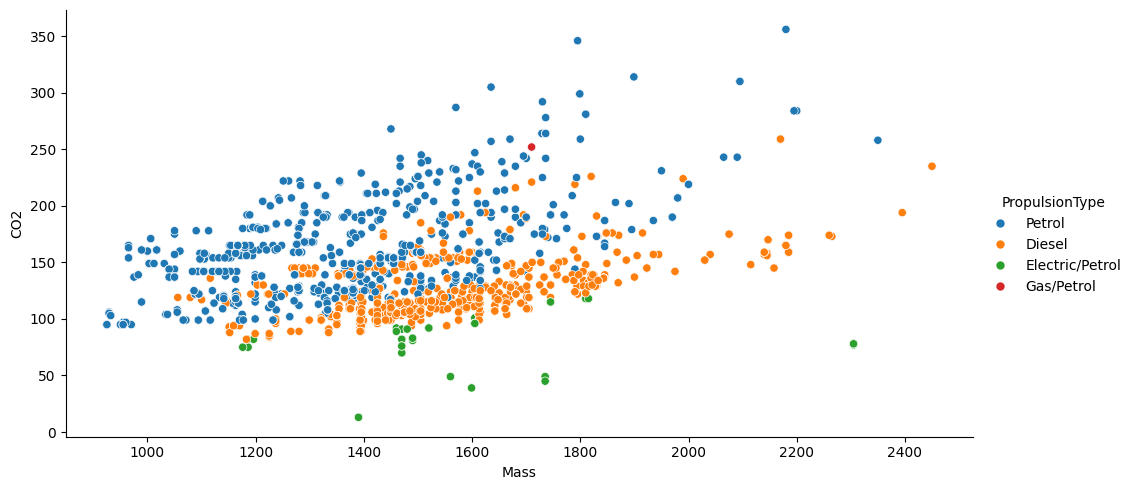

In [ ]:
# scatter plot of CO2 against Mass colour-coded by PropulsionType
sns.relplot(data=cleaned_cars_data, x='Mass', y='CO2', hue='PropulsionType', aspect=2);

> Add code below to create a scatter plot of `CO2` against `EngineSize`, colour-coded by `PropulsionType`.

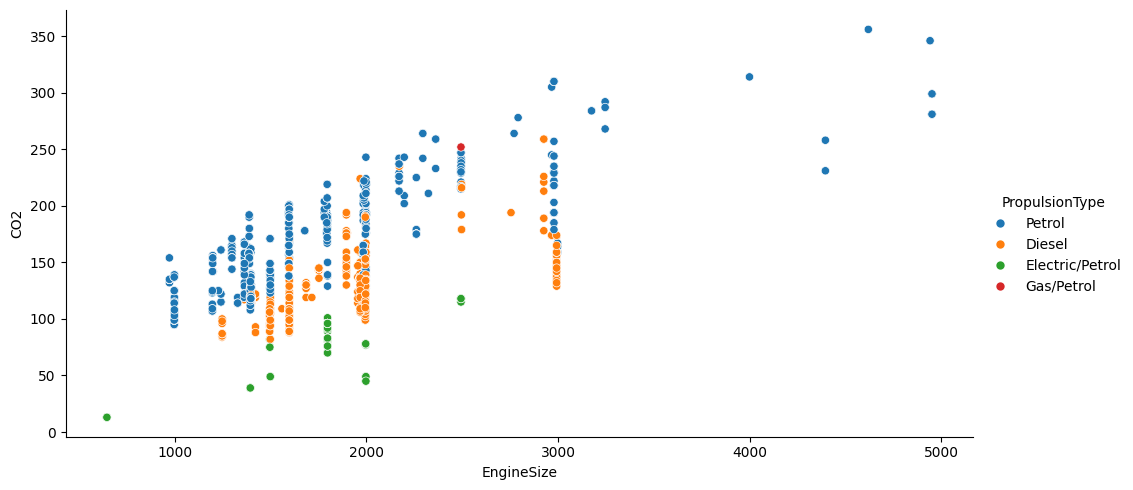

In [ ]:
# scatter plot of CO2 against EngineSize colour-coded by PropulsionType
sns.relplot(data=cleaned_cars_data, x='EngineSize', y='CO2', hue='PropulsionType', aspect=2)

## Checkpoint 1
> * Use your scatter diagrams to describe the associations between `EngineSize` and `CO2` and between `Mass` and `CO2`.
> * Suggest reasons why these associations might be expected.
> * Describe how these associations differ for different propulsion types.

# Building a model to predict CO2 emissions for petrol cars

## Pre-processing the data
The relationships appear different enough across the propulsion types that you can consider the types separately.

> Run the code below to create a data set that just contains the petrol cars.

In [ ]:
# create a data set containing only cars who PropulsionType is petrol
petrol_data = cleaned_cars_data[cleaned_cars_data['PropulsionType'] == 'Petrol'].copy()

# check the data
petrol_data

,ReferenceNumber,Make,PropulsionTypeId,BodyTypeId,GovRegion,KeeperTitleId,EngineSize,YearRegistered,Mass,CO2,CO,NOX,part,hc,Random number,PropulsionType
0,440,VAUXHALL,1,96,London,1,1598,2002,1970,190,0.219,0.026,NaN,0.037,0.430217,Petrol
1,1465,VAUXHALL,1,14,South West,5,1398,2016,1163,118,0.463,0.010,NaN,0.031,0.797111,Petrol
2,3434,VOLKSWAGEN,1,14,South West,2,1395,2016,1316,113,0.242,0.033,NaN,0.048,0.348442,Petrol
3,1801,VAUXHALL,1,14,South West,4,1598,2016,1355,159,0.809,0.012,NaN,0.051,0.968447,Petrol
6,1323,VAUXHALL,1,14,South West,5,1398,2016,1163,118,0.463,0.010,NaN,0.031,0.526516,Petrol
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3819,1903,VOLKSWAGEN,1,13,London,1,1197,2016,1139,109,0.199,0.018,NaN,0.035,0.078803,Petrol
3820,2913,FORD,1,5,North West,1,4951,2016,1799,299,0.621,0.018,NaN,0.046,0.787504,Petrol
3821,706,FORD,1,13,North West,1,1299,2002,965,154,0.395,0.103,NaN,0.061,0.934800,Petrol
3824,3498,FORD,1,14,South West,1,999,2016,1333,108,0.447,0.030,0.002,0.076,0.736612,Petrol


## Building a model

You are going to build a model that attempts to predict the $CO_2$ emissions for a car based on the values of some of the other features. The process involves the following five steps:

* Define the input and output (or target) features for the model.
* Create a *training-testing split* for the data: you will used the training data to build the model and the testing data to measure it.
* Build the model using a machine learning algorithm.
* Display the model: i.e. for a straight line model $y=mx+c$ display the values of the parameters $m$ and $c$.
* Measure the model: create a set of predictions using the testing data and compare these to the actual values from the data set.

More details on each of these steps is given in the appendix at the end of this notebook.

> Run the code block below to create and measure a model for predicting the $CO_2$ emissions from the mass of a car.

In [ ]:
# define the input feature(s) and output (or target) feature
input_features = ['Mass']
input_data = petrol_data[input_features]
target_data = petrol_data['CO2']

# use the train_test_split command to create training and testing data
input_train, input_test, target_train, target_test = train_test_split(input_data, target_data, train_size=0.75, random_state=1)

# create the model
linear_model = LinearRegression().fit(input_train, target_train)

# display the model
print('Coefficients: ', (linear_model.coef_).round(3))
print('Intercept: ', (linear_model.intercept_).round(3))

# create a list of the predictions and calculate R² by comparing with the testing data
target_pred = linear_model.predict(input_test)
print('R²: ',round(r2_score(target_test, target_pred), 3))

Coefficients:  [0.101]
Intercept:  16.57
R²:  0.355


## Interpretting the output

The output of the model is the values for $m$ and $c$ in the equation of the line $y=mx+c$. These are labelled as `Coefficients` and `Intercept` respectively.

Models can be evaluated using the measure `R²`. This is a value on a scale of 0-1, where a higher value implies a better fit to the data.

You can use your model to make some predictions for the $CO_2$ emissions of different cars. For example, your model of $y=0.101x+16.57$ would predict $CO_2$ emissions of 153.425g/km for a car of mass 1355kg, using the formula $0.101×1355+16.57$.

Use your model to calculate predictions of the $CO_2$ emissions for the cars in the table below and compare these to the true value.

| Car number | EngineSize | Mass | CO2 |
| --- | --- | --- | --- |
| 1 | 1598 | 1355 |159 |
| 2 | 1398 | 1141 | 118 |
| 3 | 998 | 1177 | 99 |

In [ ]:
# Prediction for the CO2 emissions of a car of mass 1355kg
0.101 * 1355 + 16.57

153.425

In [ ]:
# Prediction for the CO2 emissions of a car of mass 1141kg
0.101 * 1141 + 16.57

131.811

In [ ]:
# Prediction for the CO2 emissions of a car of mass 1177kg
0.101 * 1177 + 16.57

135.447

## Changing the input features for the model

You can create an alternative model for the $CO_2$ emissions by using the engine size as the input feature. To do this you would replace `Mass` with `EngineSize` in the first line of the code for building a model.

> In the box below add and run code to fit a linear model for $CO_2$ of petrol cars using `EngineSize` as the input feature:
> * Copy the previous code block with the full code for creating and measuring a model;
> * Replace `input_features = ['Mass']` with `input_features = ['EngineSize']` and run the code block.

In [ ]:
# create and measure a model to predict CO2 from EngineSize

# define the input feature(s) and output (or target) feature
input_features = ['EngineSize']
input_data = petrol_data[input_features]
target_data = petrol_data['CO2']

# use the train_test_split command to create training and testing data
input_train, input_test, target_train, target_test = train_test_split(input_data, target_data, train_size=0.75, random_state=1)

# create the model
linear_model = LinearRegression().fit(input_train, target_train)

# display the model
print('Coefficients: ', (linear_model.coef_).round(3))
print('Intercept: ', (linear_model.intercept_).round(3))

# create a list of the predictions and calculate R² by comparing with the testing data
target_pred = linear_model.predict(input_test)
print('R²: ',round(r2_score(target_test, target_pred), 3))

Coefficients:  [0.06]
Intercept:  57.087
R²:  0.643


## Checkpoint 2
> * State the equations for your lines of best fit.
> * Which input feature gives the best model for predicting $CO_2$?
> * Calculate the expected emissions using your preferred model for three cars given below. How well do these compare to the actual recorded emissions?

| Car number | EngineSize | Mass | CO2 |
| --- | --- | --- | --- |
| 1 | 1598 | 1355 |159 |
| 2 | 1398 | 1141 | 118 |
| 3 | 998 | 1177 | 99 |

In [ ]:
#Predictions for CO2 emissions for a cars with specific engine sizes
# Line of best fit: y = 0.06x + 57.087

#EngineSize = 1598
print(0.06*1598 + 57.087)

#EngineSize = 1398
print(0.06*1398 + 57.087)

#EngineSize = 998
print(0.06*998 + 57.087)

152.96699999999998
140.96699999999998
116.967


# Building a model using two input variables
The models you've built so far used a single variable but it is possible to create a prediction model using a combination of two, or more, input features.

This is difficult to visualise. You could represent a linear model  of two input variables used to predict a third value as a plane in 3D space but for more than two input variables a simple visualisation isn't viable. However, it is straightforward to write linear functions of multiple variables algebraically. For example a linear function predicting $CO_2$ emissions ($e$) based on mass ($m$) and engine size ($s$) could be written as:

$e = am + bs + c$

where $a$ and $b$ are the coefficients and $c$ is the intercept.

> Run the code in the box below to create and evaluate a model for $CO_2$ emissions as a linear function of mass and engine size

In [ ]:
# define the input feature(s) and output (or target) feature
input_features = ['Mass', 'EngineSize']
input_data = petrol_data[input_features]
target_data = petrol_data['CO2']

# use the train_test_split command to create training and testing testing data
input_train, input_test, target_train, target_test = train_test_split(input_data, target_data, train_size=0.75, random_state=1)

# create the model
linear_model = LinearRegression().fit(input_train, target_train)

# display the model
print('Coefficients: ', (linear_model.coef_).round(3))
print('Intercept: ', (linear_model.intercept_).round(3))

# create a list of the predictions and calculate R² by comparing with the testing data
target_pred = linear_model.predict(input_test)
print('R²: ',round(r2_score(target_test, target_pred), 3))

Coefficients:  [0.039 0.05 ]
Intercept:  22.311
R²:  0.673


## Checkpoint 3
> * How well does this model predict emissions compared to the models on `Mass` and `EngineSize` individually?
> * State the equation for the model.
> * Calculate the expected emissions using your linear model for the three cars given below. How well do these compare to the actual recorded emissions?

| Car number | EngineSize | Mass | CO2 |
| --- | --- | --- | --- |
| 1 | 1598 | 1355 |159 |
| 2 | 1398 | 1141 | 118 |
| 3 | 998 | 1177 | 99 |

In [ ]:
#Line of Best Fit: y = 0.05*a + 0.039*b + 22.311

#Car 1
print(0.05*1598+0.039*1355 + 22.311)

#Car 2
print(0.05*1398+0.039*1141 + 22.311)

#Car 3
print(0.05*998+0.039*1177 + 22.311)

155.056
136.71
118.114


# Building models for diesel cars

You can now try building a model to predict the $CO_2$ emissions of _diesel_ cars. First you will need to filter for the diesel cars.

> Run the code below to create a data set that just contains the diesel cars.

In [ ]:
# create a data set containing only cars who PropulsionType is petrol
diesel_data = cleaned_cars_data[cleaned_cars_data['PropulsionType'] == 'Diesel'].copy()

# check the data
diesel_data

,ReferenceNumber,Make,PropulsionTypeId,BodyTypeId,GovRegion,KeeperTitleId,EngineSize,YearRegistered,Mass,CO2,CO,NOX,part,hc,Random number,PropulsionType
4,2330,BMW,2,13,South West,5,1995,2016,1445,114,0.180,0.023,NaN,NaN,0.178227,Diesel
5,2216,FORD,2,6,South West,5,1499,2016,1425,98,0.354,0.074,NaN,NaN,0.423774,Diesel
9,2971,VOLKSWAGEN,2,6,South West,5,2967,2016,2185,174,0.138,0.039,NaN,NaN,0.225134,Diesel
11,2707,FORD,2,14,North West,5,1499,2016,1399,98,0.354,0.074,NaN,NaN,0.853962,Diesel
12,2419,VAUXHALL,2,6,South West,5,1598,2016,1393,89,0.268,0.047,NaN,NaN,0.149359,Diesel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3817,1118,TOYOTA,2,14,South West,1,1995,2002,1415,153,0.240,0.450,0.034,NaN,0.184194,Diesel
3818,326,TOYOTA,2,6,South West,1,1995,2002,1560,190,0.080,0.440,0.036,NaN,0.139254,Diesel
3822,2920,FORD,2,14,North West,5,1997,2016,1681,122,0.145,0.059,0.001,NaN,0.946550,Diesel
3823,1800,FORD,2,96,London,2,1997,2016,1833,134,0.305,0.054,NaN,NaN,0.538774,Diesel


You can now build models to predict $CO_2$ emissions of diesel cars based on mass or engine size or a combination of both.

> Add code in the box below to create a measure models:
> * using `Mass` as the input;
> * using `EngineSize` as the input;
> * using `Mass` and `EngineSize` as the input.
>
> **NB you will need to replace any instances of `petrol_data` with `diesel_data`.**

In [ ]:
# create and measure a model for CO2 emissions of diesel cars using Mass as input

# define the input feature(s) and output (or target) feature
input_features = ['Mass']
input_data = diesel_data[input_features]
target_data = diesel_data['CO2']

# use the train_test_split command to create training and testing data
input_train, input_test, target_train, target_test = train_test_split(input_data, target_data, train_size=0.75, random_state=1)

# create the model
linear_model = LinearRegression().fit(input_train, target_train)

# display the model
print('Coefficients: ', (linear_model.coef_).round(3))
print('Intercept: ', (linear_model.intercept_).round(3))

# create a list of the predictions and calculate R² by comparing with the testing data
target_pred = linear_model.predict(input_test)
print('R²: ',round(r2_score(target_test, target_pred), 3))

Coefficients:  [0.062]
Intercept:  27.043
R²:  0.393


In [ ]:
# create and measure a model for CO2 emissions of diesel cars using EngineSize as input

# define the input feature(s) and output (or target) feature
input_features = ['EngineSize']
input_data = diesel_data[input_features]
target_data = diesel_data['CO2']

# use the train_test_split command to create training and testing data
input_train, input_test, target_train, target_test = train_test_split(input_data, target_data, train_size=0.75, random_state=1)

# create the model
linear_model = LinearRegression().fit(input_train, target_train)

# display the model
print('Coefficients: ', (linear_model.coef_).round(3))
print('Intercept: ', (linear_model.intercept_).round(3))

# create a list of the predictions and calculate R² by comparing with the testing data
target_pred = linear_model.predict(input_test)
print('R²: ',round(r2_score(target_test, target_pred), 3))

Coefficients:  [0.043]
Intercept:  43.928
R²:  0.415


In [ ]:
# create and measure a model for CO2 emissions of diesel cars usng Mass and EngineSize as input

# define the input feature(s) and output (or target) feature
input_features = ['Mass', 'EngineSize']
input_data = diesel_data[input_features]
target_data = diesel_data['CO2']

# use the train_test_split command to create training and testing testing data
input_train, input_test, target_train, target_test = train_test_split(input_data, target_data, train_size=0.75, random_state=1)

# create the model
linear_model = LinearRegression().fit(input_train, target_train)

# display the model
print('Coefficients: ', (linear_model.coef_).round(3))
print('Intercept: ', (linear_model.intercept_).round(3))

# create a list of the predictions and calculate R² by comparing with the testing data
target_pred = linear_model.predict(input_test)
print('R²: ',round(r2_score(target_test, target_pred), 3))

Coefficients:  [0.033 0.029]
Intercept:  17.128
R²:  0.482


## Checkpoint 4

> * Which of these models gives the best predictions?
> * How well does this model predict the $CO_2$ emissions for the cars in the data set?

# Communicating the result

## Checkpoint 5
Use your analysis above to answer the original problem:
> Can engine size and mass be used to predict a car's emissions?

# Appendix: More details on the steps of the process

The process involves the following five steps:

* Define the input and output (or target) features for the model.
* Create a *training-testing split* for the data: you will used the training data to build the model and the testing data to measure it.
* Build the model using a machine learning algorithm.
* Display the model: i.e. for a straight line model $y=mx+c$ display the values of the parameters $m$ and $c$.
* Measure the model: create a set of predictions using the testing data and compare these to the actual values from the data set.

### Define the input and output (or target) features for the model

The output, or target, feature is the quantity you are trying to predict, in this case $CO_2$ emissions. The input feature is a numerical quantity that you will use in your formula. You can use multiple input features, as you will see in the next section, but you can only have one target feature.

### Create a *training-testing split* for the data

In mathematics, you often judge the fit of a trend line or regression line by seeing how close it is to the data it was calculated from. In data science, an alternative method is often used: most of the data (the *training* set) is used to calculate the best line, but some of it (the *testing* set) is kept back so that the model can be evaluated fairly. This is effectively the same as taking a new set of data and measuring how closely your predictions match reality. You will use the `sklearn` command `train_test_split` to create four objects:
* An input table of `Mass` or `EngineSize` values to *train* your model on.
* An output list of `CO2` values to *train* your model on.
* An input table of `Mass` or `EngineSize` values to *test* your model on.
* An output list of `CO2` values to *test* your model on.

### Build the model using a machine learning algorithm

This is where the *machine learning* takes place. The `LinearRegression` command uses an iterative, or *trial and improvement*, method to find the best possible values of $m$ and $c$ for your data.

### Display the model
For a straight line model $y=mx+c$ you will get the values of the parameters $m$ and $c$.

### Measure the model
In this activity you are trying to create a model that will predict $CO_2$ emissions in terms of other features. This model can be evaluated by using the _coefficient of determination_, *R*². This number is calculated with the testing data by comparing a list of the predictions, using the model, to a list of the true values.  

*R*² indicates how well the input features predict the target on a scale of 0-1. For example, *R*²=0.35 would indicate that 35% of the variation in emissions is accounted for by variation in mass. The other 65% of variation in emissions might be accounted for by other features, or it might be just random. **A higher value of *R*² indicates that your model is a better fit to the data.**

When the model is a simple linear function of one variable (as it is in A level Mathematics), *R*² is just the same as *r*², the square of the PMCC value. The *R*² measure is often preferred in data science contexts. For more details see: https://en.wikipedia.org/wiki/Coefficient_of_determination
